# ASESMEN AKHIR SEMESTER
## UTS – Computer Vision (RE604)

---

| | |
|---|---|
| **Nama** | Sistra Amanda Sinaga |
| **NIM** | 4222301011 |
| **Mata Kuliah** | Computer Vision (RE604) |
| **Kelas** | 6A Pagi |
| **Program Studi** | Teknik Robotika |
| **Institusi** | Politeknik Negeri Batam |
| **Dosen** | Eko Rudiawan Jamzuri |
| **Tahun Akademik** | Genap 2026 |

---

### Judul:
**Klasifikasi Karakter  pada Dataset EMNIST menggunakan HOG Feature Extraction dan Support Vector Machine (SVM) dengan Evaluasi Leave-One-Out Cross-Validation (LOOCV)**

---
## 📦 Install Library yang Dibutuhkan

In [5]:
!pip install scikit-image scikit-learn matplotlib seaborn tqdm numpy -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Import Library

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, f1_score, classification_report
)
import warnings
import time
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
print(' Semua library berhasil diimport!')

 Semua library berhasil diimport!


---
## 2. Konfigurasi Parameter HOG & SVM

### Parameter HOG:
| Parameter | Nilai | Keterangan |
|---|---|---|
| `orientations` | 9 | Jumlah bin arah gradien |
| `pixels_per_cell` | (4, 4) | Ukuran cell dalam piksel |
| `cells_per_block` | (2, 2) | Jumlah cell per block normalisasi |
| `block_norm` | L2-Hys | Metode normalisasi |
| `transform_sqrt` | True | Gamma correction sebelum HOG |

### Parameter SVM:
| Parameter | Nilai | Keterangan |
|---|---|---|
| `kernel` | rbf | Radial Basis Function |
| `C` | 10.0 | Parameter regularisasi |
| `gamma` | scale | Koefisien kernel otomatis |

In [11]:
# ============================================================
# LOKASI FILE CSV — taruh di folder yang sama dengan notebook
# ============================================================
CSV_TRAIN = 'emnist-letters-train.csv'

# ----- Parameter HOG -----
HOG_PARAMS = {
    'orientations'    : 9,        # jumlah bin orientasi gradien
    'pixels_per_cell' : (4, 4),   # ukuran cell dalam piksel
    'cells_per_block' : (2, 2),   # cell per block untuk normalisasi
    'block_norm'      : 'L2-Hys', # metode normalisasi block
    'transform_sqrt'  : True,     # gamma correction
}

# ----- Parameter SVM -----
SVM_PARAMS = {
    'C'                      : 10.0,
    'kernel'                 : 'rbf',
    'gamma'                  : 'scale',
    'decision_function_shape': 'ovr',
    'random_state'           : 42,
}

# ----- Sampel untuk LOOCV -----
N_SAMPLES_PER_CLASS = 15   # 15 sampel × 26 kelas = 390 iterasi LOOCV
N_CLASSES           = 26
CLASS_NAMES         = [chr(ord('a') + i) for i in range(N_CLASSES)]

print(' Konfigurasi parameter berhasil!')
print(f'   HOG orientations    : {HOG_PARAMS["orientations"]}')
print(f'   HOG pixels_per_cell : {HOG_PARAMS["pixels_per_cell"]}')
print(f'   HOG cells_per_block : {HOG_PARAMS["cells_per_block"]}')
print(f'   HOG block_norm      : {HOG_PARAMS["block_norm"]}')
print(f'   SVM kernel          : {SVM_PARAMS["kernel"]}')
print(f'   SVM C               : {SVM_PARAMS["C"]}')
print(f'   SVM gamma           : {SVM_PARAMS["gamma"]}')
print(f'   Sampel/kelas (LOOCV): {N_SAMPLES_PER_CLASS}')

 Konfigurasi parameter berhasil!
   HOG orientations    : 9
   HOG pixels_per_cell : (4, 4)
   HOG cells_per_block : (2, 2)
   HOG block_norm      : L2-Hys
   SVM kernel          : rbf
   SVM C               : 10.0
   SVM gamma           : scale
   Sampel/kelas (LOOCV): 15


---
## 3. Pemrosesan Data dari Dataset EMNIST

Dataset **EMNIST Letters** memiliki format CSV:
- Kolom pertama = **label** (1–26, mewakili huruf a–z)
- Kolom 2–785 = **nilai piksel** (28×28 = 784 piksel, grayscale)

Langkah preprocessing:
1. Baca CSV → pisahkan label dan piksel
2. Reshape piksel menjadi gambar 28×28
3. Koreksi orientasi (rotate + flip) khusus EMNIST
4. Normalisasi piksel ke rentang [0, 1]
5. Ambil subset seimbang (jumlah sampel sama setiap kelas)

In [12]:
def load_emnist_csv(csv_path):
    """
    Membaca dataset EMNIST dari file CSV.
    Kolom 0     = label (1-26)
    Kolom 1-784 = piksel (28x28 = 784)
    """
    print(f'Membaca {csv_path} ... (harap tunggu ~30 detik)')
    data   = np.genfromtxt(csv_path, delimiter=',', dtype=np.uint8)
    labels = data[:, 0] - 1        # konversi label 1-26 → 0-25
    pixels = data[:, 1:]           # ambil kolom piksel
    images = pixels.reshape(-1, 28, 28)

    # Koreksi orientasi EMNIST (rotate 270° + horizontal flip)
    images = np.rot90(images, k=3, axes=(1, 2))
    images = np.flip(images, axis=2)
    return images, labels


def prepare_subset(images, labels, n_per_class, n_classes, seed=42):
    """Ambil n_per_class sampel secara acak dari setiap kelas."""
    rng      = np.random.RandomState(seed)
    idx_list = []
    for cls in range(n_classes):
        cls_idx = np.where(labels == cls)[0]
        chosen  = rng.choice(cls_idx,
                             size=min(n_per_class, len(cls_idx)),
                             replace=False)
        idx_list.append(chosen)
    all_idx = np.concatenate(idx_list)
    rng.shuffle(all_idx)
    return images[all_idx], labels[all_idx]


# Load dataset
images_all, labels_all = load_emnist_csv(CSV_TRAIN)
print(f'✅ Dataset dimuat: {len(images_all)} gambar, {N_CLASSES} kelas (a–z)')

# Ambil subset seimbang
X_sub, y_sub = prepare_subset(images_all, labels_all, N_SAMPLES_PER_CLASS, N_CLASSES)
print(f'✅ Subset: {len(X_sub)} sampel ({N_SAMPLES_PER_CLASS}/kelas × {N_CLASSES} kelas)')

# Normalisasi piksel ke [0, 1]
X_pre = X_sub.astype(np.float32) / 255.0
print('✅ Normalisasi piksel selesai!')

Membaca emnist-letters-train.csv ... (harap tunggu ~30 detik)
✅ Dataset dimuat: 88800 gambar, 26 kelas (a–z)
✅ Subset: 390 sampel (15/kelas × 26 kelas)
✅ Normalisasi piksel selesai!


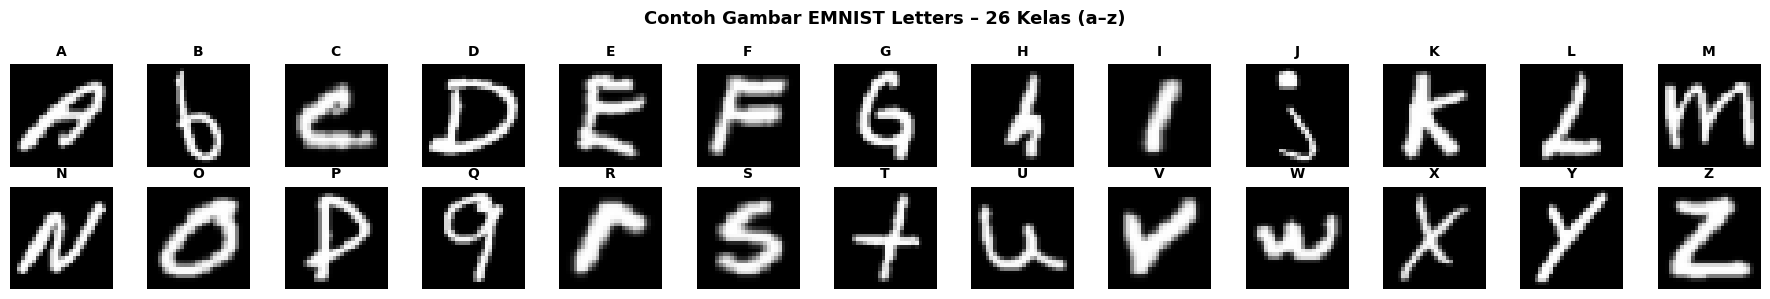

✅ sample_dataset.png tersimpan!


In [13]:
# Tampilkan contoh gambar setiap kelas
fig, axes = plt.subplots(2, 13, figsize=(18, 3))
axes = axes.flatten()
for i in range(N_CLASSES):
    idx = np.where(y_sub == i)[0][0]
    axes[i].imshow(X_pre[idx], cmap='gray')
    axes[i].set_title(CLASS_NAMES[i].upper(), fontsize=10, fontweight='bold')
    axes[i].axis('off')
for j in range(N_CLASSES, len(axes)):
    axes[j].axis('off')
fig.suptitle('Contoh Gambar EMNIST Letters – 26 Kelas (a–z)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ sample_dataset.png tersimpan!')

---
## 4. Ekstraksi Fitur HOG (Histogram of Oriented Gradients)

HOG menghitung **distribusi arah gradien** pada sel-sel lokal gambar.
Fitur HOG mampu menangkap **bentuk dan tepi karakter** dengan baik,
dan bersifat *robust* terhadap perubahan pencahayaan.

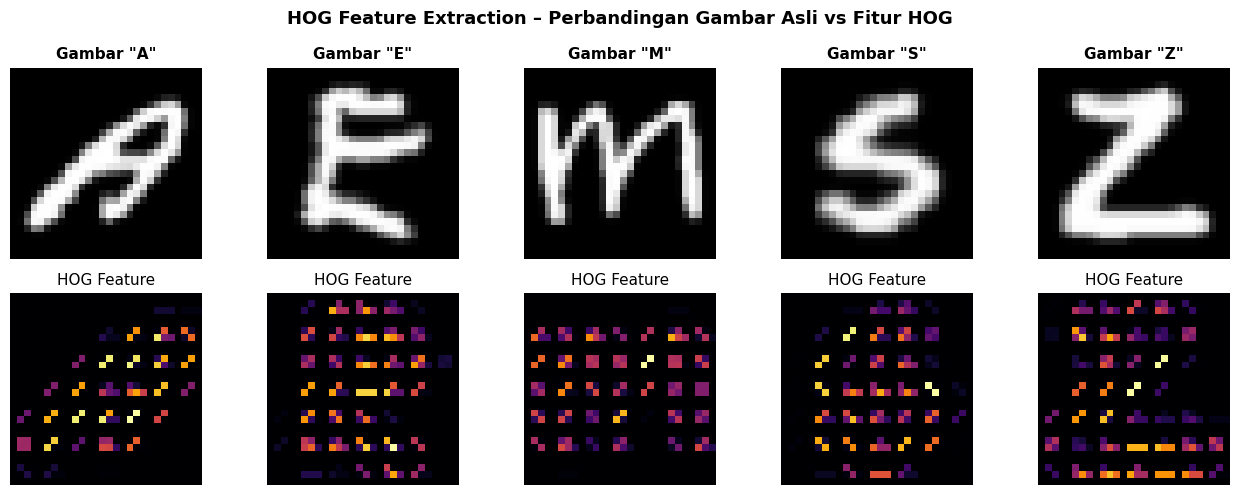

✅ hog_visualization.png tersimpan!


In [14]:
# Visualisasi HOG pada beberapa contoh huruf
sample_letters = ['a', 'e', 'm', 's', 'z']
fig, axes = plt.subplots(2, len(sample_letters), figsize=(13, 5))

for col, letter in enumerate(sample_letters):
    cls_idx = ord(letter) - ord('a')
    img_idx = np.where(y_sub == cls_idx)[0][0]
    img     = X_pre[img_idx]
    _, hog_img = hog(img, **HOG_PARAMS, visualize=True)

    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'Gambar "{letter.upper()}"', fontsize=11, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(hog_img, cmap='inferno')
    axes[1, col].set_title('HOG Feature', fontsize=11)
    axes[1, col].axis('off')

fig.suptitle('HOG Feature Extraction – Perbandingan Gambar Asli vs Fitur HOG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ hog_visualization.png tersimpan!')

In [22]:
# Ekstraksi HOG untuk semua sampel
X_hog = []
for img in tqdm(X_pre, desc='Ekstraksi HOG'):
    X_hog.append(hog(img, **HOG_PARAMS))
X_hog = np.array(X_hog)

print(f'✅ Ekstraksi HOG selesai!')
print(f'   Jumlah sampel      : {X_hog.shape[0]}')
print(f'   Dimensi fitur HOG  : {X_hog.shape[1]} per gambar')







Ekstraksi HOG: 100%|██████████| 390/390 [00:00<00:00, 1682.78it/s]

✅ Ekstraksi HOG selesai!
   Jumlah sampel      : 390
   Dimensi fitur HOG  : 1296 per gambar


---
## 5. Metode Evaluasi: Leave-One-Out Cross-Validation (LOOCV)

**LOOCV** bekerja dengan cara:
- Diberikan **N** total sampel → lakukan **N iterasi**
- Setiap iterasi: **1 sampel** sebagai data uji, **N-1 sampel** sisanya sebagai data latih
- Setelah semua iterasi → hitung metrik dari seluruh prediksi

**Keunggulan LOOCV:**
- Tidak ada data yang terbuang (semua dipakai untuk training)
- Estimasi performa paling tidak bias
- Cocok untuk dataset berukuran kecil

In [23]:
print('=' * 55)
print('  EVALUASI: Leave-One-Out Cross-Validation (LOOCV)')
print('=' * 55)
print(f'  Total sampel    : {len(y_sub)}')
print(f'  Total iterasi   : {len(y_sub)} (1 per sampel)')
print(f'  Data latih/iter : {len(y_sub)-1} sampel')
print(f'  Data uji/iter   : 1 sampel')
print(f'  Klasifier       : SVM (kernel={SVM_PARAMS["kernel"]}, C={SVM_PARAMS["C"]})')
print('=' * 55)
print('\nMemulai LOOCV ... (harap tunggu ~2-3 menit)')

loo    = LeaveOneOut()
model  = SVC(**SVM_PARAMS)
t0     = time.time()

y_pred = cross_val_predict(model, X_hog, y_sub, cv=loo, n_jobs=-1, verbose=0)

elapsed = time.time() - t0
print(f'\n✅ LOOCV selesai dalam {elapsed:.1f} detik!')

  EVALUASI: Leave-One-Out Cross-Validation (LOOCV)
  Total sampel    : 390
  Total iterasi   : 390 (1 per sampel)
  Data latih/iter : 389 sampel
  Data uji/iter   : 1 sampel
  Klasifier       : SVM (kernel=rbf, C=10.0)

Memulai LOOCV ... (harap tunggu ~2-3 menit)

✅ LOOCV selesai dalam 10.2 detik!


---
## 6. Perolehan Hasil Metrik Evaluasi

In [24]:
acc  = accuracy_score(y_sub, y_pred)
prec = precision_score(y_sub, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_sub, y_pred, average='macro', zero_division=0)

print('=' * 60)
print('  HASIL EVALUASI LOOCV – Sistra Amanda Sinaga')
print('  UTS Computer Vision RE604 – Kelas 6A Pagi')
print('=' * 60)
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  Precision  : {prec*100:.2f}%  (macro-average)')
print(f'  F1-Score   : {f1*100:.2f}%  (macro-average)')
print('=' * 60)
print()
print('Classification Report per Kelas:')
print(classification_report(y_sub, y_pred, target_names=CLASS_NAMES, zero_division=0))

  HASIL EVALUASI LOOCV – Sistra Amanda Sinaga
  UTS Computer Vision RE604 – Kelas 6A Pagi
  Accuracy   : 68.21%
  Precision  : 69.57%  (macro-average)
  F1-Score   : 68.29%  (macro-average)

Classification Report per Kelas:
              precision    recall  f1-score   support

           a       0.37      0.47      0.41        15
           b       0.59      0.67      0.62        15
           c       0.81      0.87      0.84        15
           d       0.88      0.47      0.61        15
           e       0.83      0.67      0.74        15
           f       0.85      0.73      0.79        15
           g       0.40      0.40      0.40        15
           h       0.40      0.53      0.46        15
           i       0.67      0.53      0.59        15
           j       0.71      0.80      0.75        15
           k       0.93      0.93      0.93        15
           l       0.60      0.60      0.60        15
           m       0.83      0.67      0.74        15
           n       

---
## 7. Confusion Matrix

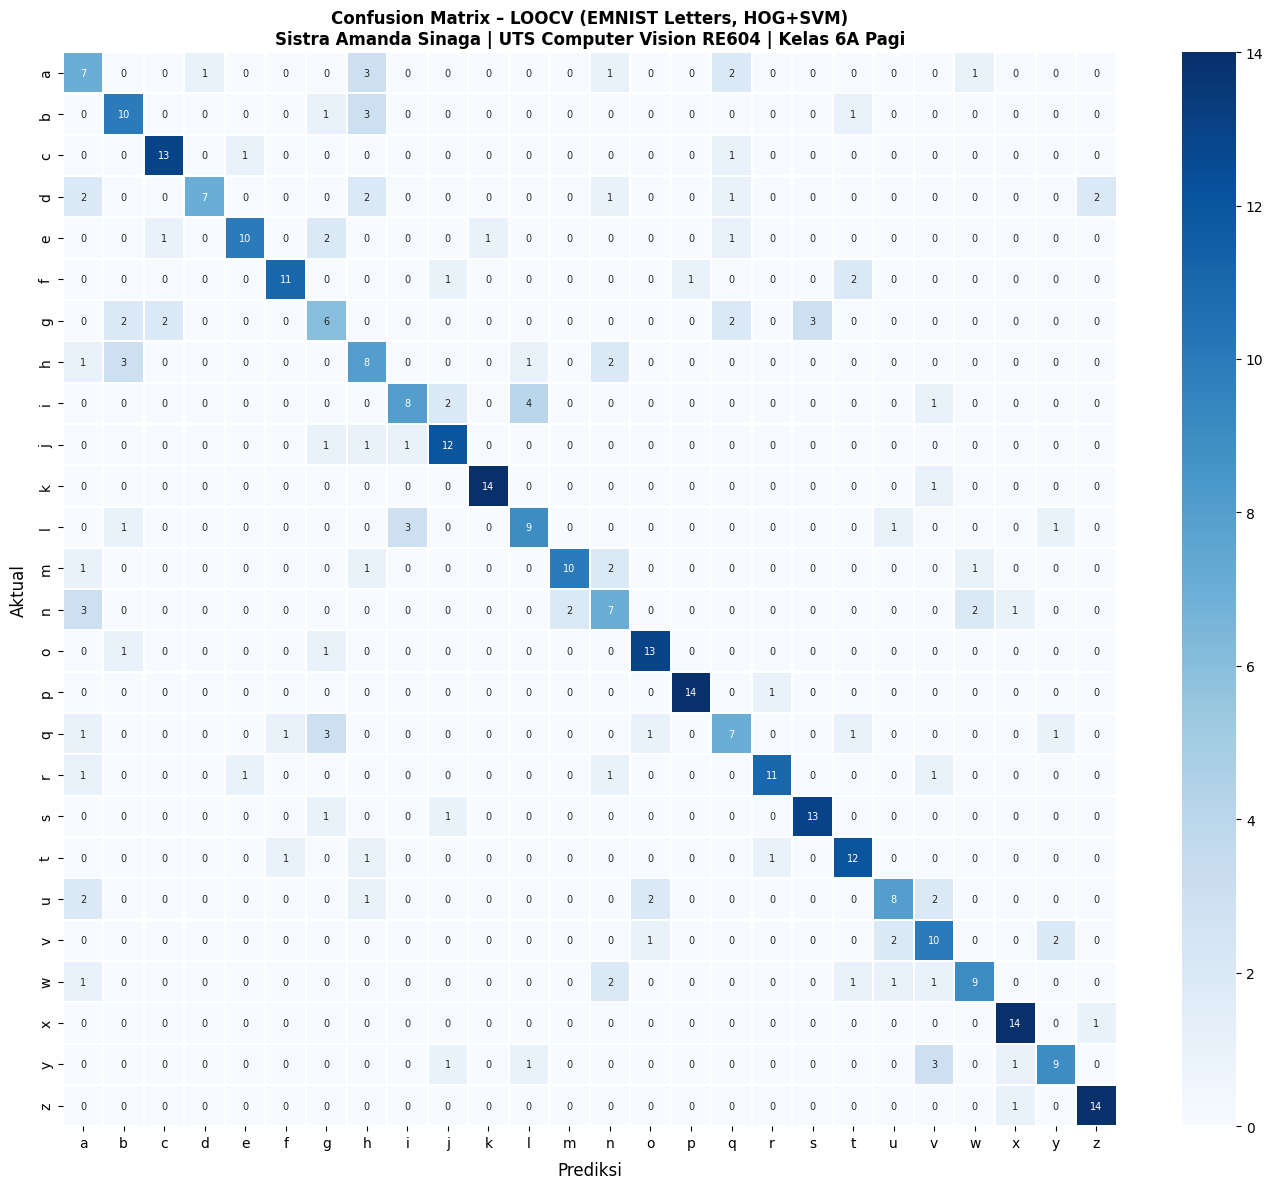

✅ confusion_matrix.png tersimpan!


In [25]:
cm = confusion_matrix(y_sub, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_xlabel('Prediksi', fontsize=12, labelpad=8)
ax.set_ylabel('Aktual',   fontsize=12, labelpad=8)
ax.set_title(
    'Confusion Matrix – LOOCV (EMNIST Letters, HOG+SVM)\n'
    'Sistra Amanda Sinaga | UTS Computer Vision RE604 | Kelas 6A Pagi',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix.png tersimpan!')

---
## 8. Grafik Metrik Evaluasi

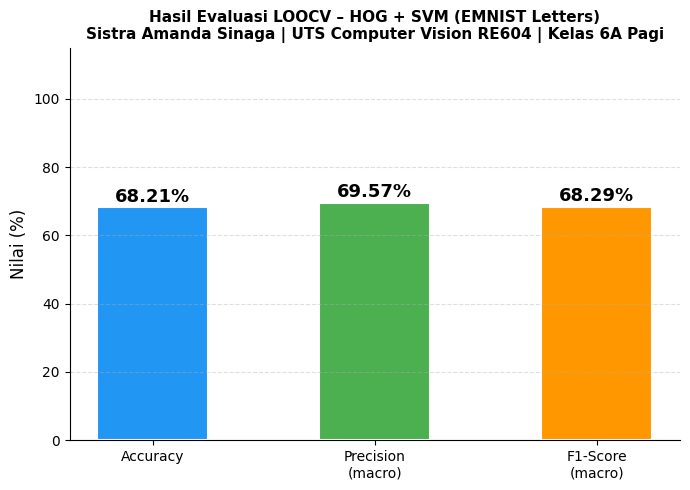

✅ metrics_bar.png tersimpan!


In [26]:
metrics = ['Accuracy', 'Precision\n(macro)', 'F1-Score\n(macro)']
values  = [acc*100, prec*100, f1*100]
colors  = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics, values, color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{v:.2f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('Nilai (%)', fontsize=12)
ax.set_title(
    'Hasil Evaluasi LOOCV – HOG + SVM (EMNIST Letters)\n'
    'Sistra Amanda Sinaga | UTS Computer Vision RE604 | Kelas 6A Pagi',
    fontsize=11, fontweight='bold'
)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ metrics_bar.png tersimpan!')

---
## 9.Hasil Prediksi

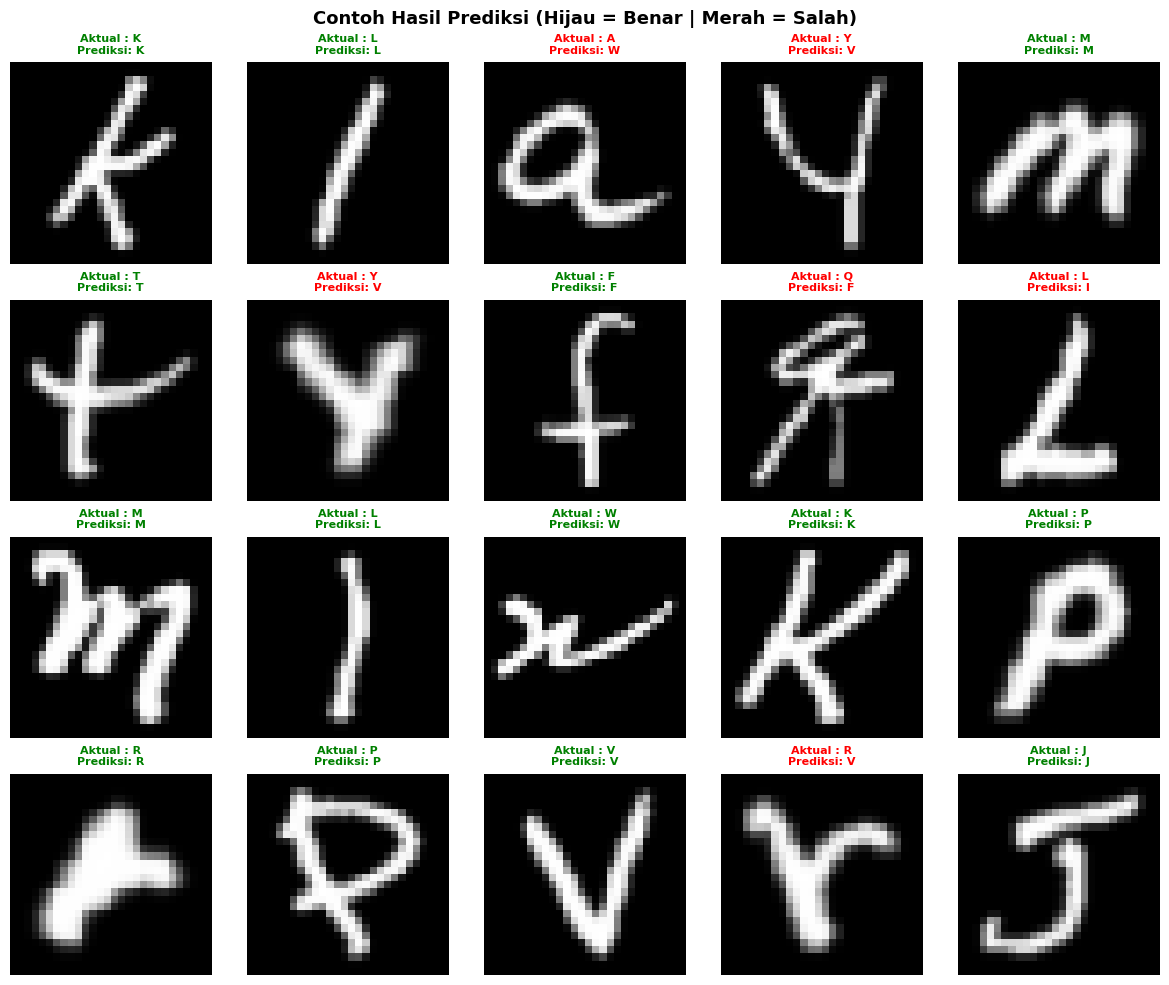

✅ sample_predictions.png tersimpan!


In [29]:
np.random.seed(7)
idx_list = np.random.choice(len(y_sub), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, idx in zip(axes.flatten(), idx_list):
    ax.imshow(X_sub[idx], cmap='gray')
    color = 'green' if y_sub[idx] == y_pred[idx] else 'red'
    ax.set_title(
        f'Aktual : {CLASS_NAMES[y_sub[idx]].upper()}\n'
        f'Prediksi: {CLASS_NAMES[y_pred[idx]].upper()}',
        color=color, fontsize=8, fontweight='bold'
    )
    ax.axis('off')
fig.suptitle('Contoh Hasil Prediksi (Hijau = Benar | Merah = Salah)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ sample_predictions.png tersimpan!')

---
## 10. Ringkasan Akhir

In [30]:
print('=' * 60)
print('  RINGKASAN AKHIR')
print('  Sistra Amanda Sinaga | 4222301011')
print('  UTS Computer Vision RE604 – Kelas 6A Pagi')
print('  Politeknik Negeri Batam | Genap 2024/2025')
print('=' * 60)
print(f'  Dataset          : EMNIST Letters (a–z, 26 kelas)')
print(f'  Jumlah Sampel    : {len(X_sub)} ({N_SAMPLES_PER_CLASS}/kelas)')
print(f'  HOG orientations : {HOG_PARAMS["orientations"]}')
print(f'  HOG pix/cell     : {HOG_PARAMS["pixels_per_cell"]}')
print(f'  HOG cell/block   : {HOG_PARAMS["cells_per_block"]}')
print(f'  HOG block_norm   : {HOG_PARAMS["block_norm"]}')
print(f'  SVM kernel       : {SVM_PARAMS["kernel"]}')
print(f'  SVM C            : {SVM_PARAMS["C"]}')
print(f'  SVM gamma        : {SVM_PARAMS["gamma"]}')
print(f'  Evaluasi         : LOOCV ({len(y_sub)} iterasi)')
print(f'  ----------------------------------------')
print(f'  Accuracy         : {acc*100:.2f}%')
print(f'  Precision (macro): {prec*100:.2f}%')
print(f'  F1-Score (macro) : {f1*100:.2f}%')
print('=' * 60)
print()
print('  Output tersimpan:')
print('    ✅ confusion_matrix.png')
print('    ✅ metrics_bar.png')
print('    ✅ sample_predictions.png')
print('    ✅ hog_visualization.png')
print('    ✅ sample_dataset.png')

  RINGKASAN AKHIR
  Sistra Amanda Sinaga | 4222301011
  UTS Computer Vision RE604 – Kelas 6A Pagi
  Politeknik Negeri Batam | Genap 2024/2025
  Dataset          : EMNIST Letters (a–z, 26 kelas)
  Jumlah Sampel    : 390 (15/kelas)
  HOG orientations : 9
  HOG pix/cell     : (4, 4)
  HOG cell/block   : (2, 2)
  HOG block_norm   : L2-Hys
  SVM kernel       : rbf
  SVM C            : 10.0
  SVM gamma        : scale
  Evaluasi         : LOOCV (390 iterasi)
  ----------------------------------------
  Accuracy         : 68.21%
  Precision (macro): 69.57%
  F1-Score (macro) : 68.29%

  Output tersimpan:
    ✅ confusion_matrix.png
    ✅ metrics_bar.png
    ✅ sample_predictions.png
    ✅ hog_visualization.png
    ✅ sample_dataset.png
